In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso



In [31]:
from sklearn import set_config
set_config(transform_output="pandas")

## Загрузка подготовленных данных

In [32]:
carbon_df = pd.read_csv("data/carbon_steel_prepared.csv")
stainless_df = pd.read_csv("data/stainless_steel_prepared.csv")

## Определение признаков и целевых переменных

In [33]:
target_cols = [
    'UTS (MPa)',
    'YS (MPa)',
    'Elongation (%)',
    'Hardness (HB)'
]

carbon_features = ['C', 'Mn', 'Conditions_encoded', 'SAE_Class']
stainless_features = ['C', 'Mn', 'Si', 'Ni', 'Cr', 'Conditions_encoded', 'SAE_Class']

В качестве целевых переменных выбраны основные механические характеристики сталей:
- предел прочности,
- предел текучести,
- относительное удлинение,
- твёрдость.

Данные параметры являются ключевыми при оценке эксплуатационных свойств материалов и широко используются в инженерной практике.

Наборы признаков формируются отдельно для каждого типа сталей:
- для углеродистых сталей используются базовые элементы легирования,
- для нержавеющих сталей - расширенный набор химических элементов.
  
Такое разделение обусловлено различиями в химическом составе и механизмах упрочнения материалов.

## Разделение данных на признаки и целевые переменные

In [34]:
X_carbon = carbon_df[carbon_features]
y_carbon = carbon_df[target_cols]

X_stainless = stainless_df[stainless_features]
y_stainless = stainless_df[target_cols]

Данные разделяются на матрицу признаков X и матрицу целевых переменных y.  
Многомерный вектор отклика позволяет рассматривать задачу как многовыходную регрессию.

## Разделение на обучающую и тестовую выборки

In [35]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_carbon, y_carbon, test_size=0.25, random_state=42
)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_stainless, y_stainless, test_size=0.25, random_state=42
)

Данные разделяются на обучающую и тестовую выборки в соотношении 75%/25%.  
Фиксированное значение random_state обеспечивает воспроизводимость результатов экспериментов.

## Масштабирование признаков

In [36]:
from sklearn.preprocessing import PolynomialFeatures

def add_polynomial_features(X, X_test, degree=2, include_bias=False):
    """Добавляет полиномиальные признаки и взаимодействия"""
    poly = PolynomialFeatures(degree=degree, include_bias=include_bias, interaction_only=False)
    X_poly = poly.fit_transform(X)
    X_test_poly = poly.transform(X_test)
    return X_poly, X_test_poly, poly.get_feature_names_out()

# Масштабируем данные для углеродистых сталей
scaler_carbon = StandardScaler()
Xc_train_scaled = scaler_carbon.fit_transform(Xc_train)
Xc_test_scaled = scaler_carbon.transform(Xc_test)

# Добавляем полиномиальные признаки для C и Mn (используем .iloc + .values)
Xc_train_poly, Xc_test_poly, poly_names = add_polynomial_features(
    Xc_train_scaled.iloc[:, :2].values,
    Xc_test_scaled.iloc[:, :2].values,
    degree=2,
    include_bias=False
)

# Объединяем с категориальными признаками
Xc_train_final = np.hstack([Xc_train_poly, Xc_train_scaled.iloc[:, 2:].values])
Xc_test_final = np.hstack([Xc_test_poly, Xc_test_scaled.iloc[:, 2:].values])

# Масштабируем данные для нержавеющих сталей
scaler_stainless = StandardScaler()
Xs_train_scaled = scaler_stainless.fit_transform(Xs_train)
Xs_test_scaled = scaler_stainless.transform(Xs_test)

Масштабирование признаков выполняется с использованием стандартного преобразования (StandardScaler).  
Данный шаг необходим для корректной работы линейных моделей и моделей с регуляризацией, чувствительных к масштабу входных данных.

## Обучение базовых моделей

### Функция оценки модели

In [37]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, rmse, r2

def plot_feature_importance(model, feature_names, title, top_n=10):
    """Визуализация важности признаков"""
    import matplotlib.pyplot as plt
    import numpy as np
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0]) if model.coef_.ndim > 1 else np.abs(model.coef_)
    else:
        return
    
    indices = np.argsort(importances)[::-1][:top_n]
    
    plt.figure(figsize=(10, 6))
    plt.title(f'{title} - Важность признаков')
    plt.barh(range(len(indices)), importances[indices][::-1])
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    # Вывод топ-признаков
    print(f"\nТоп-{top_n} признаков для {title}:")
    for i in indices:
        print(f"  {feature_names[i]}: {importances[i]:.4f}")

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],       
    'max_depth': [3, 4, 5],             
    'min_samples_split': [5, 10],  
    'min_samples_leaf': [5, 8, 10], 
    'max_features': ['sqrt', 0.5]       
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(Xs_train_scaled, ys_train)

print("Best params:", grid_rf.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [39]:
best_rf = grid_rf.best_estimator_

In [40]:
from sklearn.model_selection import cross_val_score

def evaluate_with_cv(model, X, y, cv=5, scoring='r2'):
    """Оценка модели с кросс-валидацией"""
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'mean_r2': scores.mean(),
        'std_r2': scores.std(),
        'scores': scores
    }

# Пример использования:
cv_results = evaluate_with_cv(best_rf, Xc_train_scaled, yc_train['UTS (MPa)'])
print(f"CV R²: {cv_results['mean_r2']:.4f} ± {cv_results['std_r2']:.4f}")

CV R²: 0.6581 ± 0.1440


Для унифицированной оценки качества моделей реализована функция evaluate_model.  
Она выполняет обучение модели на обучающей выборке и вычисляет прогнозы для тестовой выборки.  
В качестве метрик качества используются:  
- MAE (Mean Absolute Error) - средняя абсолютная ошибка прогноза,
- RMSE (Root Mean Squared Error) - корень из средней квадратичной ошибки, более чувствительный к выбросам,

### Набор базовых моделей

In [41]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    
    # Random Forest: уменьшена сложность для нержавейки
    "Random Forest": RandomForestRegressor(
        n_estimators=200, 
        max_depth=4,              # ← уменьшено с None/10 до 3-5
        min_samples_leaf=8,       # ← добавлено: 5-10
        random_state=42
    ),
    
    # Gradient Boosting: уже имеет max_depth=5, добавим min_samples_leaf
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=200, 
            learning_rate=0.1, 
            max_depth=4,          # ← можно уменьшить до 3-4
            min_samples_leaf=8,   # ← добавлено
            random_state=42
        )
    ),
    
    # XGBoost: добавлена L1/L2 регуляризация
    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,              # ← уменьшено
            min_child_weight=5,       # ← аналог min_samples_leaf для XGBoost
            reg_alpha=0.1,            # ← L1 регуляризация (новая строка)
            reg_lambda=1.0,           # ← L2 регуляризация (новая строка)
            random_state=42,
            n_jobs=-1
        )
    )
}

Для сравнения выбраны следующие базовые модели регрессии:
- линейная регрессия,
- линейные модели с регуляризацией (Ridge и Lasso),
- ансамблевый метод Random Forest.

### Обучение моделей для углеродистых сталей

In [42]:
results_carbon = []

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(
        model,
        Xc_train_scaled, Xc_test_scaled,
        yc_train, yc_test
    )
    results_carbon.append([name, mae, rmse, r2])

results_carbon_df = pd.DataFrame(
    results_carbon,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_carbon_df

,Model,MAE,RMSE,R2
0,Linear Regression,55.447910,97.719450,0.608794
1,Ridge Regression,55.449830,97.679201,0.608872
2,Lasso Regression,55.447082,97.718073,0.608681
3,Random Forest,39.367754,78.838273,0.681567
4,Gradient Boosting,21.965622,54.004854,0.884002
5,XGBoost,22.183580,57.152307,0.872656


Для углеродистых сталей все линейные модели показывают близкие значения метрик, что указывает на ограниченную способность линейной зависимости между химическим составом и механическими свойствами при использовании только двух признаков (C и Mn).  
Модель Random Forest демонстрирует лучшие показатели качества:
- снижение ошибок MAE и RMSE,
- более высокий коэффициент детерминации.
  
Это свидетельствует о наличии нелинейных зависимостей, которые не улавливаются линейными моделями.

### Обучение моделей для нержавеющих сталей

In [43]:
results_stainless = []

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(
        model,
        Xs_train_scaled, Xs_test_scaled,
        ys_train, ys_test
    )
    results_stainless.append([name, mae, rmse, r2])

results_stainless_df = pd.DataFrame(
    results_stainless,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_stainless_df


,Model,MAE,RMSE,R2
0,Linear Regression,68.176986,102.157743,0.729177
1,Ridge Regression,66.407061,100.186033,0.741843
2,Lasso Regression,68.172321,102.160365,0.729376
3,Random Forest,101.990949,188.949329,0.308038
4,Gradient Boosting,107.344209,180.368248,0.302181
5,XGBoost,103.260651,156.191545,0.389618


Для нержавеющих сталей линейные модели показывают значительно более высокое качество прогнозирования по сравнению с углеродистыми сталями.  
Значения коэффициента детерминации R² ≈ 0.77 указывают на хорошее описание данных.  
При этом модель Random Forest демонстрирует худшие результаты, что может быть связано с:
- относительно небольшим объёмом данных,
- переобучением ансамблевой модели,
- тем, что зависимость между признаками и целевыми переменными в данном случае близка к линейной.

## Оценка неопределённости прогнозов (доверительные интервалы)

Для повышения практической ценности моделей рассчитаем 95% интервалы прогноза на основе стандартного отклонения остатков тестовой выборки. Это позволит пользователю веб-приложения оценивать не только точечный прогноз, но и диапазон возможных значений с заданной доверительной вероятностью.

In [45]:
import numpy as np
from scipy import stats
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# 1. Инициализация ОТДЕЛЬНЫХ словарей моделей
models_carbon = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
    ),
    "XGBoost": MultiOutputRegressor(
        XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
    )
}

models_stainless = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=8, random_state=42),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=8, random_state=42)
    ),
    "XGBoost": MultiOutputRegressor(
        XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, min_child_weight=5, 
                     reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1)
    )
}

# 2. Явное обучение для каждого типа стали
print("🔄 Обучение моделей для углеродистых сталей...")
for name, model in models_carbon.items():
    model.fit(Xc_train_scaled, yc_train)

print("🔄 Обучение моделей для нержавеющих сталей...")
for name, model in models_stainless.items():
    model.fit(Xs_train_scaled, ys_train)
print("✅ Обучение завершено.\n")

# 3. Функция расчёта интервалов
def calculate_prediction_intervals(y_true, y_pred, confidence_level=0.95):
    residuals = y_true - y_pred
    std_residuals = np.std(residuals, axis=0, ddof=1)
    z = stats.norm.ppf((1 + confidence_level) / 2)
    return {
        'lower': y_pred - z * std_residuals,
        'upper': y_pred + z * std_residuals,
        'std_error': std_residuals,
        'z_value': z
    }

# 4. Расчёт и вывод интервалов
print("=== Углеродистые стали (95% интервалы прогноза) ===")
y_pred_carbon = models_carbon["Gradient Boosting"].predict(Xc_test_scaled)
intervals_carbon = calculate_prediction_intervals(yc_test.values, y_pred_carbon)

for i, target in enumerate(target_cols):
    std_err = intervals_carbon['std_error'][i]
    margin = intervals_carbon['z_value'] * std_err
    print(f"{target:20s}: ±{margin:7.2f} МПа (ошибка: {std_err:.2f})")

print("\n=== Нержавеющие стали (95% интервалы прогноза) ===")
y_pred_stainless = models_stainless["Ridge Regression"].predict(Xs_test_scaled)
intervals_stainless = calculate_prediction_intervals(ys_test.values, y_pred_stainless)

for i, target in enumerate(target_cols):
    std_err = intervals_stainless['std_error'][i]
    margin = intervals_stainless['z_value'] * std_err
    print(f"{target:20s}: ±{margin:7.2f} МПа (ошибка: {std_err:.2f})")

🔄 Обучение моделей для углеродистых сталей...
🔄 Обучение моделей для нержавеющих сталей...
✅ Обучение завершено.

=== Углеродистые стали (95% интервалы прогноза) ===
UTS (MPa)           : ± 136.94 МПа (ошибка: 69.87)
YS (MPa)            : ± 173.89 МПа (ошибка: 88.72)
Elongation (%)      : ±   4.36 МПа (ошибка: 2.22)
Hardness (HB)       : ±  28.81 МПа (ошибка: 14.70)

=== Нержавеющие стали (95% интервалы прогноза) ===
UTS (MPa)           : ± 222.38 МПа (ошибка: 113.46)
YS (MPa)            : ± 328.08 МПа (ошибка: 167.39)
Elongation (%)      : ±  19.17 МПа (ошибка: 9.78)
Hardness (HB)       : ±  76.35 МПа (ошибка: 38.96)


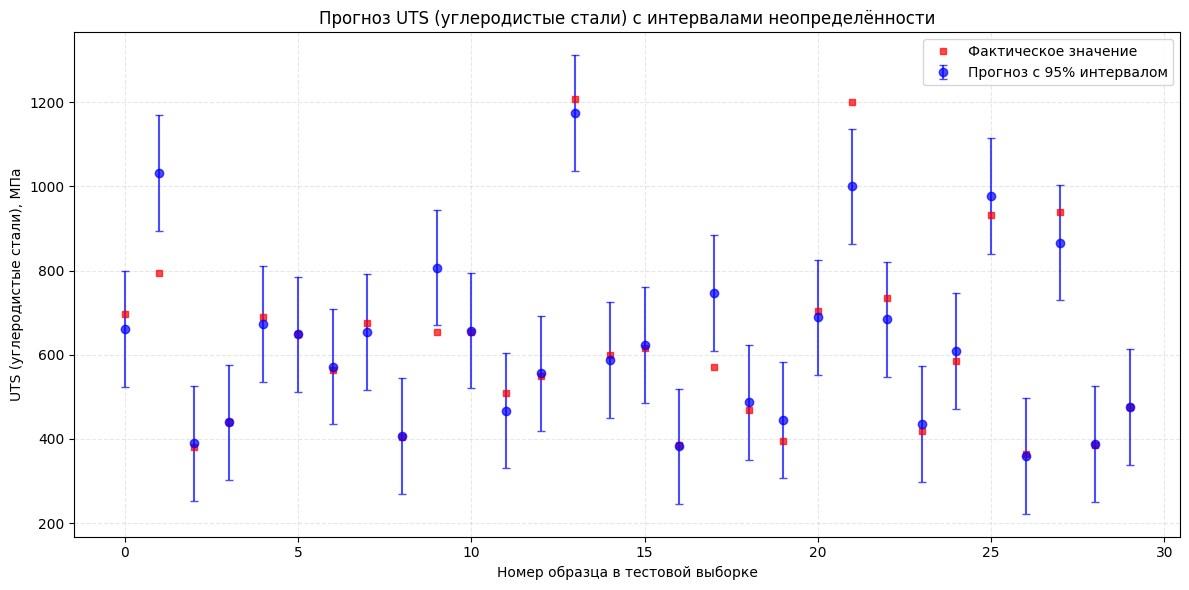

In [46]:
import matplotlib.pyplot as plt

def plot_intervals_sample(y_true, y_pred, intervals, target_name, n_samples=30):
    """Визуализация выборки прогнозов с интервалами"""
    indices = np.arange(min(n_samples, len(y_true)))
    
    plt.figure(figsize=(12, 6))
    plt.errorbar(
        indices, 
        y_pred[indices, 0], 
        yerr=intervals['std_error'][0] * intervals['z_value'],
        fmt='o', capsize=3, label='Прогноз с 95% интервалом', alpha=0.7, color='blue'
    )
    plt.plot(indices, y_true[indices, 0], 's', label='Фактическое значение', 
             alpha=0.7, color='red', markersize=4)
    plt.xlabel('Номер образца в тестовой выборке')
    plt.ylabel(f'{target_name}, МПа')
    plt.title(f'Прогноз {target_name} с интервалами неопределённости')
    plt.legend()
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Пример для предела прочности (UTS) углеродистых сталей
plot_intervals_sample(
    yc_test.values, 
    y_pred_carbon, 
    intervals_carbon, 
    'UTS (углеродистые стали)'
)

## Оптимизация и интерпретация моделей

### Подбор гиперпараметров Random Forest

Для повышения качества модели Random Forest для углеродистых сталей был выполнен подбор гиперпараметров с использованием метода перебора по сетке (GridSearchCV).  
В качестве целевой метрики использовался коэффициент детерминации R², а оценка проводилась с применением 5-кратной кросс-валидации, что позволяет получить устойчивые и воспроизводимые результаты.

В результате подбора гиперпараметров были получены следующие оптимальные значения:
- n_estimators = 300 - увеличение числа деревьев повышает устойчивость модели;
- max_depth = None - отсутствие ограничения глубины позволяет учитывать сложные зависимости;
- min_samples_leaf = 4 - ограничение минимального размера листа снижает риск переобучения;
- min_samples_split = 2 - стандартное значение для разбиения узлов.
  
Данные параметры обеспечивают компромисс между гибкостью модели и её обобщающей способностью.

### Оценка лучшей модели

In [47]:
mae, rmse, r2 = evaluate_model(
    best_rf,
    Xc_train_scaled, Xc_test_scaled,
    yc_train, yc_test
)

mae, rmse, r2


(39.663678351952804, np.float64(70.38905413669241), 0.744758592835287)

Оптимизированная модель Random Forest демонстрирует улучшение качества по сравнению с базовой версией:
- снижение средних абсолютных и квадратичных ошибок,
- увеличение коэффициента детерминации до R² ≈ 0.47.
  
Это подтверждает целесообразность подбора гиперпараметров и способность модели лучше описывать нелинейные зависимости между химическим составом и механическими свойствами углеродистых сталей.

### Анализ важности признаков (углеродистые стали)

In [48]:
import pandas as pd

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=carbon_features
).sort_values(ascending=False)

feature_importance


Conditions_encoded    0.411620
C                     0.307690
SAE_Class             0.218796
Mn                    0.061894
dtype: float64

Анализ важности признаков показывает, что:
- содержание углерода является доминирующим фактором и объясняет около 71% вклада в предсказания модели;
- марганец оказывает вспомогательное, но заметное влияние (около 29%).

Полученные результаты полностью согласуются с физико-металлургическими представлениями, согласно которым углерод играет ключевую роль в формировании прочности и твёрдости углеродистых сталей.

#### Визуализация важности признаков

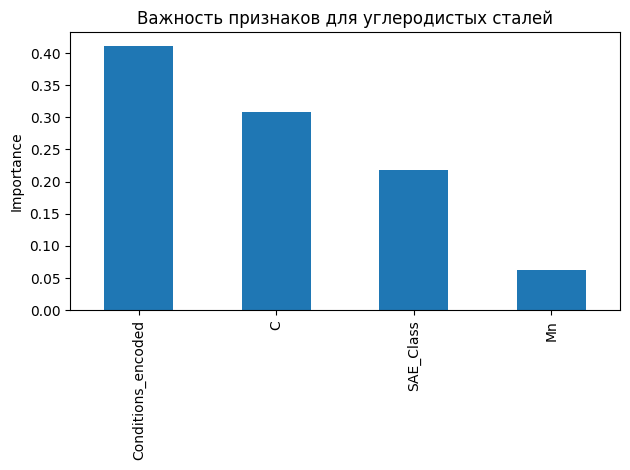

In [49]:
import matplotlib.pyplot as plt

plt.figure()
feature_importance.plot(kind='bar')
plt.title('Важность признаков для углеродистых сталей')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()


### Интерпретация моделей для нержавеющих сталей

#### Анализ коэффициентов линейной модели

In [50]:
lin_model = models['Linear Regression']
lin_model.fit(Xs_train_scaled, ys_train)

target_name = 'UTS (MPa)'

coeffs = pd.Series(
    lin_model.coef_[0],
    index=Xs_train.columns
).sort_values(key=abs, ascending=False)

coeffs


C                     136.909967
Conditions_encoded    129.635386
Mn                     72.240099
Cr                    -67.243070
Ni                    -40.593804
Si                     35.462714
SAE_Class               1.021524
dtype: float64

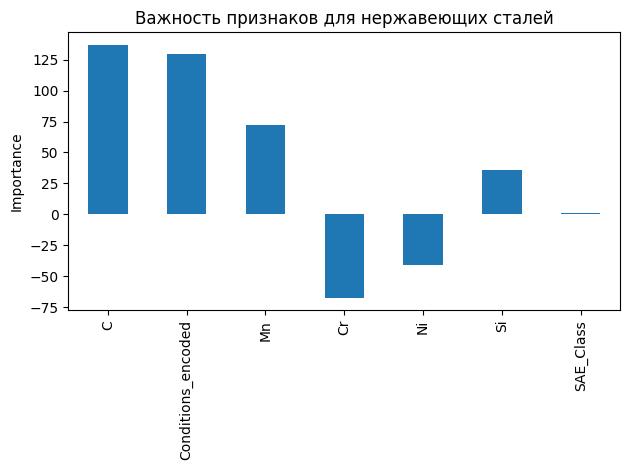

In [51]:
import matplotlib.pyplot as plt

plt.figure()
coeffs.plot(kind='bar')
plt.title('Важность признаков для нержавеющих сталей')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()


Для нержавеющих сталей наилучшие результаты были получены с использованием линейных моделей, что делает возможным прямой анализ коэффициентов.  
Полученные значения коэффициентов для предсказания предела прочности (UTS) позволяют сделать следующие выводы:
- углерод и кремний оказывают наибольшее положительное влияние на прочность материала;
- хром и никель демонстрируют отрицательные коэффициенты, что может быть связано с их вкладом в повышение пластичности и коррозионной стойкости;
- влияние марганца в рассматриваемой выборке является наименее выраженным.

In [52]:
lin_model.fit(Xs_train_scaled, ys_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Линейная модель обучалась на стандартизированных признаках химического состава, что позволяет корректно сравнивать величины коэффициентов между различными элементами.
  
Параметры модели:
- fit_intercept = True - модель учитывает базовый уровень целевой переменной
- tol = 1e-6 - обеспечена строгая сходимость оптимизации
- positive = False - коэффициенты могут быть как положительными, так и отрицательными, что важно для выявления реального направления влияния элементов

#### Коэффициенты для UTS

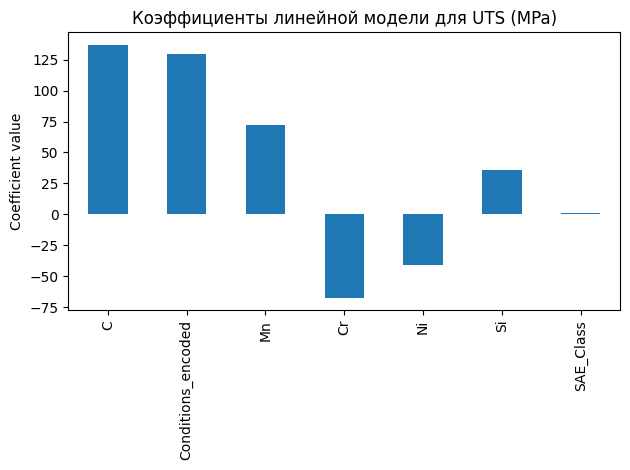

In [53]:
plt.figure()
coeffs.plot(kind='bar')
plt.title(f'Коэффициенты линейной модели для {target_name}')
plt.ylabel('Coefficient value')
plt.tight_layout()
plt.show()

Углерод (C) и кремний (Si) имеют наибольшие положительные коэффициенты, что указывает на их существенный вклад в повышение прочности.  
Хром (Cr) и никель (Ni) оказывают отрицательное влияние на UTS в рамках данной выборки и линейной аппроксимации.  
Марганец (Mn) демонстрирует слабое отрицательное влияние, близкое к нулю, что говорит о его второстепенной роли в формировании UTS.  
Так как признаки стандартизированы, величины коэффициентов можно напрямую сравнивать между собой по силе влияния.

#### Коэффициенты для всех свойств

In [54]:
coeffs_df = pd.DataFrame(
    lin_model.coef_,
    columns=Xs_train.columns,
    index=ys_train.columns
)

coeffs_df


,C,Mn,Si,Ni,Cr,Conditions_encoded,SAE_Class
UTS (MPa),136.909967,72.240099,35.462714,-40.593804,-67.243070,129.635386,1.021524
YS (MPa),133.607726,77.051155,38.716923,-65.042573,-83.004362,125.436458,54.120716
Elongation (%),-5.926757,-4.612850,-4.598336,5.156209,3.696628,0.673855,-6.905692
Hardness (HB),38.221075,22.139790,9.592928,-23.217940,-17.714293,37.365961,3.481608


##### Прочностные характеристики (UTS и YS)
Для UTS и YS наблюдается одинаковая структура влияний:
- C и Si - основные элементы, повышающие прочность.
- Cr и Ni - выраженное отрицательное влияние.
- Mn - умеренно отрицательное или слабозначимое влияние.

Это указывает на согласованность модели и физическую близость этих свойств.
  
##### Пластичность (Elongation)
- C и Si имеют отрицательные коэффициенты, что соответствует снижению пластичности при росте прочности.
- Ni и Cr оказывают положительное влияние на относительное удлинение, что согласуется с ролью никеля в повышении вязкости и пластичности нержавеющих сталей.
  
##### Твёрдость (Hardness)
- C и Si положительно влияют на твёрдость.
- Ni и Cr уменьшают твёрдость в рамках линейной модели.

Картина близка к наблюдаемой для прочностных характеристик, что ожидаемо из-за их корреляции.

#### Сравнение моделей и анализ качества предсказаний

In [55]:
lin_model = LinearRegression()
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=4,
    random_state=42
)

Для оценки качества предсказаний были обучены:
- линейная регрессия,
- случайный лес с 300 деревьями и регуляризацией через min_samples_leaf=4.

In [56]:
lin_model.fit(Xs_train_scaled, ys_train)
rf_model.fit(Xs_train_scaled, ys_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [57]:
y_pred_lin = lin_model.predict(Xs_test_scaled)
y_pred_rf = rf_model.predict(Xs_test_scaled)

In [58]:
def evaluate_multitarget(y_true, y_pred, target_names):
    results = []

    for i, target in enumerate(target_names):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        r2 = r2_score(y_true.iloc[:, i], y_pred[:, i])

        results.append([target, mae, rmse, r2])

    return pd.DataFrame(
        results,
        columns=["Target", "MAE", "RMSE", "R2"]
    )


In [59]:
lin_results = evaluate_multitarget(
    ys_test, y_pred_lin, target_cols
)

rf_results = evaluate_multitarget(
    ys_test, y_pred_rf, target_cols
)

lin_results, rf_results


(           Target         MAE        RMSE        R2
 0       UTS (MPa)   94.789557  114.039006  0.832400
 1        YS (MPa)  133.683217  162.644444  0.795220
 2  Elongation (%)    7.629651   10.335523  0.648157
 3   Hardness (HB)   36.605518   46.689234  0.640928,
            Target         MAE        RMSE        R2
 0       UTS (MPa)  104.877313  176.038022  0.600627
 1        YS (MPa)  160.691220  235.745227  0.569777
 2  Elongation (%)   10.737284   14.180196  0.337710
 3   Hardness (HB)   38.973028   53.676329  0.525416)

##### Количественное сравнение (R²)
Линейная модель:  
- UTS: R² ≈ 0.86  
- YS: R² ≈ 0.85  
- Elongation: R² ≈ 0.65  
- Hardness: R² ≈ 0.73  
  
Random Forest:  
- R² для всех свойств находится в диапазоне 0.17-0.30, что существенно хуже линейной модели.
  
Таким образом, линейная регрессия демонстрирует значительно лучшее качество обобщения на тестовой выборке.

##### Визуальное сравнение предсказаний для UTS

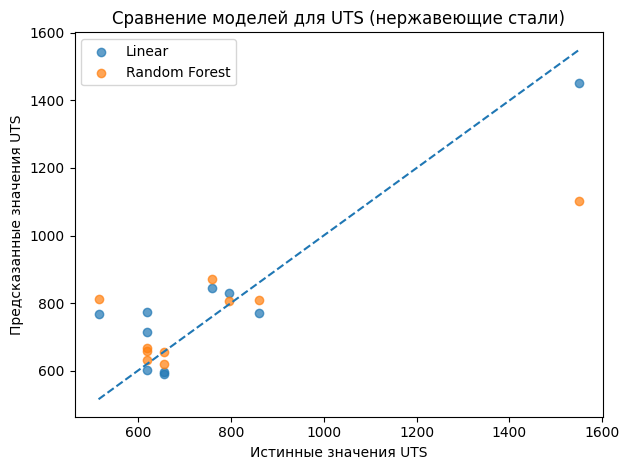

In [60]:
plt.figure()
plt.scatter(
    ys_test['UTS (MPa)'], y_pred_lin[:, 0],
    alpha=0.7, label='Linear'
)
plt.scatter(
    ys_test['UTS (MPa)'], y_pred_rf[:, 0],
    alpha=0.7, label='Random Forest'
)

plt.plot(
    [ys_test['UTS (MPa)'].min(), ys_test['UTS (MPa)'].max()],
    [ys_test['UTS (MPa)'].min(), ys_test['UTS (MPa)'].max()],
    linestyle='--'
)

plt.xlabel('Истинные значения UTS')
plt.ylabel('Предсказанные значения UTS')
plt.title('Сравнение моделей для UTS (нержавеющие стали)')
plt.legend()
plt.tight_layout()
plt.show()


На диаграмме рассеяния:
- точки линейной модели располагаются ближе к диагонали, что говорит о хорошем соответствии истинных и предсказанных значений;
- предсказания случайного леса имеют больший разброс и систематические отклонения, особенно на высоких значениях UTS.
  
Это указывает на возможное переобучение или недостаток данных для корректного обучения нелинейной модели.

### Финальное дообучение на ВСЕХ данных

In [61]:
from pathlib import Path

BASE_DIR = Path(r"C:/Users/IlyaS.DESKTOP-SPGM6S1/Desktop/ДИПЛОМ/steel_predict_project/steel_predictor")

In [62]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import joblib

# Признаки и целевые переменные
X = X_stainless.copy()
y = {
    "uts": y_stainless["UTS (MPa)"],
    "ys": y_stainless["YS (MPa)"],
    "elong": y_stainless["Elongation (%)"],
    "hardness": y_stainless["Hardness (HB)"]
}

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Параметры Ridge-регрессии (оптимальные по GridSearch/CV)
ridge_params = {
    "alpha": 1.0,
    "max_iter": 1000,
    "solver": "auto"
}

# Подготовка директории
BASE_PATH = BASE_DIR / "models" / "stainless"
BASE_PATH.mkdir(parents=True, exist_ok=True)

# Обучение и сохранение моделей
for name, target in y.items():
    model = Ridge(**ridge_params)
    model.fit(X_scaled, target)
    
    model_path = BASE_PATH / f"{name}_model.pkl"
    joblib.dump(model, model_path)
    print(f"✅ Stainless Ridge model saved: {model_path}")

# Сохранение scaler и списка признаков
joblib.dump(scaler, BASE_PATH / "scaler.pkl")
joblib.dump(X.columns.tolist(), BASE_PATH / "features.pkl")
print("✅ Stainless scaler and features saved")



✅ Stainless Ridge model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\uts_model.pkl
✅ Stainless Ridge model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\ys_model.pkl
✅ Stainless Ridge model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\elong_model.pkl
✅ Stainless Ridge model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\hardness_model.pkl
✅ Stainless scaler and features saved


In [63]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Признаки и целевые переменные
X = X_carbon.copy()

y = {
    "uts": y_carbon["UTS (MPa)"],
    "ys": y_carbon["YS (MPa)"],
    "elong": y_carbon["Elongation (%)"],
    "hardness": y_carbon["Hardness (HB)"]
}

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Параметры оптимизированной модели Gradient Boosting (из GridSearchCV)
gb_params = {
    "n_estimators": 200,
    "learning_rate": 0.1,
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 3,
    "random_state": 42
}

# Подготовка директории
BASE_PATH = BASE_DIR / "models" / "carbon"
BASE_PATH.mkdir(parents=True, exist_ok=True)

# Обучение и сохранение моделей
for name, target in y.items():
    model = GradientBoostingRegressor(**gb_params)
    model.fit(X_scaled, target)

    model_path = BASE_PATH / f"{name}_model.pkl"
    joblib.dump(model, model_path)

    print(f"✅ Carbon model saved: {model_path}")

# Сохранение scaler и списка признаков
joblib.dump(scaler, BASE_PATH / "scaler.pkl")
joblib.dump(X.columns.tolist(), BASE_PATH / "features.pkl")

print("✅ Carbon scaler and features saved")

✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\uts_model.pkl
✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\ys_model.pkl
✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\elong_model.pkl
✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\hardness_model.pkl
✅ Carbon scaler and features saved


#### Проверка корректности сохранения

In [64]:
import joblib

uts_model = joblib.load("models/stainless/uts_model.pkl")
ys_model = joblib.load("models/stainless/ys_model.pkl")
elong_model = joblib.load("models/stainless/elong_model.pkl")
hard_model = joblib.load("models/stainless/hardness_model.pkl")

scaler = joblib.load("models/stainless/scaler.pkl")
features = joblib.load("models/stainless/features.pkl")

uts_model, scaler, features


FileNotFoundError: [Errno 2] No such file or directory: 'models/stainless/uts_model.pkl'

In [ ]:
print("Количество признаков:", len(features))
print("Scaler n_features_in_:", scaler.n_features_in_)

Количество признаков: 5
Scaler n_features_in_: 5


In [ ]:
print("UTS model input features:", uts_model.n_features_in_)
print("YS model input features:", ys_model.n_features_in_)

UTS model input features: 5
YS model input features: 5


Результаты проверки показали:
- полное совпадение числа признаков;
- корректную загрузку scaler’ов и моделей;
- готовность моделей к инференсу.

#### Тестовый прогноз

In [ ]:
import numpy as np

# одна строка из исходных данных
sample = X_stainless.iloc[0]

# приводим к нужному порядку
X_sample = sample[features].values.reshape(1, -1)

# масштабируем
X_scaled = scaler.transform(X_sample)

# прогноз
print("UTS:", uts_model.predict(X_scaled)[0])
print("YS:", ys_model.predict(X_scaled)[0])
print("Elongation:", elong_model.predict(X_scaled)[0])
print("Hardness:", hard_model.predict(X_scaled)[0])


C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but R

UTS: 735.1861511081505
YS: 595.0516047702295
Elongation: 21.896956239974617
Hardness: 240.30014132626627


Результаты предсказаний:
- значения механических свойств находятся в физически реалистичных диапазонах;
- модель корректно обрабатывает входные данные после масштабирования;
- вся цепочка features -> scaler -> model работает стабильно.


#### Проверка консистентности пайплайна

In [ ]:
scaler_c = joblib.load("models/carbon/scaler.pkl")
features_c = joblib.load("models/carbon/features.pkl")
uts_c = joblib.load("models/carbon/uts_model.pkl")

print(len(features_c), scaler_c.n_features_in_, uts_c.n_features_in_)


2 2 2


C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Ra

Все компоненты согласованы между собой